### This version uses the cosine of star inclination

This only affects 3 cells required for:

- transformation from cos(star_i) to star_i before the call to starry (and vsini* if needed)
- parameter labelling (param_names and tex_names)


2024 August 23: SJF

I've added a few new cells here, to calculate a few more derived quantities in the outputs (psi, beta, star_i).

But you really need to calculate the error bars on all those derived quantities also. 

1. You can do this by standard propagation of errors: eg, for y = cos(star_i) (as you have it), if you know error on the cosine, y, what is the error on star_i itself?

For $y = f(x)$:
$$
\Delta y = \partial y/\partial x \times \Delta x
$$
So if $y = \cos x$:
$$
\Delta y = -\sin x . \Delta x
$$
Hence, taking the absolute values only:
$$
\Delta x = \Delta y/\sin x = \Delta (\cos x)/\sin x
$$

But you must take care, $\Delta x$ here is in radians, so that needs converting back to degrees. I have given an example of this error propagation and conversion in the code below.

2. For other parameters, where there are quire a few variables, you can combine the uncertainties with standard propagation of errors. But this can be problematic if the expressions are very fiddly, or if the variables are correlated, as they might be. This is true for $\cos\psi$, as both $i_{orb}$ and $i_{star}$ appear in separate terms in cos and sin. So one option here, which I've illustrated in a cell below, is to read each line of parameters in the trace, after the burn-in, and then calculate $\psi$ (or $v\sin i_{star}$, or anything else) each time to build a population of derived values for that parameter. You can then get the stats on that value, in the same way as for the other parameters.

I've done this in a fairly clumsy way, but added a couple of extra defs to help:

(a) def param_stats (so you can give it an array of values and get the stats back)

(b) def psi_calc (to calculate psi) -- which I tested with your 2024 values.

So you can (eg) calculate any derived value repeatedly, once for each line of the trace, and get the parameter statistics. Eg, try this for star_i and compare with the formal propagation of errors, they should come out about the same.

In [1]:
# Brewer
import numpy as np
import numpy.random as rng
import matplotlib.pyplot as plt
import copy


# Other imports
from astropy.io import ascii
import os
import glob

In [2]:
# Starry stuff
import starry

In [3]:
starry.config.lazy = False
starry.config.quiet = True

In [4]:
class _host(object):
    """
    Generic star class.    Serves as template for specific star properties.
    """
    def __init__(self): 
        self.name = ''
        self.teff  = 0.0          # Host stellar Teff in K
        self.logg  = 0.0          # log g (cgs)
        self.logg_err = 0.0
        self.radius = 0.0         # *spherical* stellar radius in solar radii
        self.requ = 0.0           # *equatorial* stellar radius in solar radii
        self.requ_err = 0.0
        self.rpol = 0.0           # *polar* stellar radius in solar radii
        self.mass = 0.0           # stellar mass in solar masses
        self.mass_err = 0.0
        self.ld1  = 0.0           # quadratic limb-darkening coeff. 1
        self.ld2  = 0.0           # quadratic limb-darkening coeff. 2
        self.rotinc = 0.0         # stellar rotational inclination in degrees
        self.rotinc_err = 0.0
        self.obl = 0.0            # stellar obliquity
        self.obl_err = 0.0
        self.vsini = 0.0 
        self.vsini_err = 0.0      # stellar vsini in km/sec                

class HAT_P_70(_host):
    """
    HAT_P_70
    """
    def __init__(self): 
        self.name = 'HAT_P_70'
        self.teff  = 8450.0       # Host stellar Teff in K
        self.logg  = 4.181         # log g (cgs)
        self.logg_err = 0.05
        self.radius = 1.858        # *spherical* stellar radius in solar radii
        self.requ = 2.170           # *equatorial* stellar radius in solar radii 
        self.requ_err = 0.02
        self.mass = 1.890           # stellar mass in solar masses
        self.mass_err = 0.010
        self.ld1  = 0.1870         # quadratic limb-darkening coeff. 1
        self.ld2  = 0.2672         # quadratic limb-darkening coeff. 2
        self.rotinc = 55.0         # stellar rotational inclination in degrees 
        self.rotinc_err = 9.5
        self.obl = 0.037
        self.obl_err = 0.040
        self.vsini = 99.9
        self.vsini_err = 0.06      # stellar vsini in km/sec   ALL PARAMETERS FROM Cauley P. W. & Ahlers J. P. - 2022     
        
class _planet(object):
    """
    Generic planet class.
    
    Serves as template for specific planet properties.
    """
    def __init__(self): 
        self.name = ''
        self.radius = 0.0           # Published planet radius in jupiter radii
        self.mass   = 0.0           # Planet mass in solar mass
        self.orbinc = 0.0           # orbital inclination in degrees 
        sel.orbinc_err = 0.0
        self.Omega  = 0.0           # projected spin-orbit misalignment in degrees
        self.Omega_err = 0.0
        self.porb   = 0.0           # orbital period in days
        self.arstar = 0.0           # a/R* from published transit
        self.rprs   = 0.0           # Rp/R* from published transit
        self.rprs_err = 0.0
        self.asemi  = 0.0           # semi-major axis in AU
        self.bparam = 0.0           # b parameter (in units of stellar radii)
        

class HAT_P_70b(_planet):
    """
    HAT_P_70b
    """
    def __init__(self): 
        self.name = 'HAT_P_70b'
        self.radius = 1.87          # Published planet radius in jupiter radii
        self.mass   = 2.88          # Planet mass in jupiter mass
        self.orbinc = 96.50         # orbital inclination in degrees 
        self.orbinc_err = 1.2
        self.Omega  = 113.10       # projected spin-orbit misalignment in degrees 
        self.Omega_err = 4.0
        self.porb   = 2.744     # orbital period in days 
        self.arstar = 5.450         # a/R* from published transit
        self.rprs   = 0.09887         # Rp/R* from published transit 
        self.rprs_err = 0.001
        self.asemi  = 0.04739      # semi-major axis in AU 
        self.bparam = -0.629       # b parameter  PLANETARY PARAMETERS TAKEN FROM Zhou G. et al. - 2019




In [5]:
#Constants for scalar rescaling (where needed)

R_jup = 6.9911e7     # metres
R_sun = 6.95508e8
AU = 1.495978707e11

M_jup = 1.89813e27   # kg
M_sun = 1.9884099e30

day_secs = 86400.0

In [6]:
def vsini_calc(radius, mass, rotinc, obl):
    '''
    Calculates vsini from system parameters
    This assumes that the radius passed is the equatorial radius (in case of an oblate star)
    
    Input:
       radius - stellar radius in solar radii
       mass - stellar mass in solar masses
       rotinc - stellar "north pole" rotation axis inclination in degrees, 
                measured from zero in line of sight (=90 degrees in plane of the sky)
       obl - stellar obliquity, = (1 - Rpole/Requator), 0 for spherical star, 1/3 at breakup
    
    Output:
       vsini -- stellar equatorial rotational velocity in km/sec
    
    '''
    
    import numpy as np
    from astropy.constants import G
    
    G2 = G.value
    #M_star = (mass * u.Msun).to(u.kg)
    M_star = mass * M_sun
    #R_star = (radius * u.Rsun).to(u.m)
    R_star = radius * R_sun
    
    radinc = rotinc*np.pi/180.0
    
    vs = (np.sqrt(obl)/((1.0-obl))**(1.0/6.0)) * np.sqrt(G2*M_star*2.0/R_star) * np.sin(radinc)
    
    return(vs/1000.0)

In [7]:
def sma_calc(period, mass, radius):
    
    import numpy as np
    import astropy.units as u
    from astropy.constants import G
    
    G2 = G.value
    #M_star = (mass * u.Msun).to(u.kg)
    M_star = mass * M_sun
    #R_star = (radius * u.Rsun).to(u.m)
    R_star = radius * R_sun
    #p = (period * u.day).to(u.s)
    p = period * day_secs
    
    a = (((p**2.0) * G2 * M_star)/(4.0 * np.pi**2.0))**((1.0)/(3.0))
    #au1 = (a).to(u.au)
    au1 = a / AU
    arstar = a/R_star
    
    return (au1, arstar)

In [8]:
def star_grav(f):
    
    beta = (
        -74.61562401*f**5
        +53.25102994*f**4
        -14.26673657*f**3
        +1.73631257*f**2
        -0.40595372*f
        +0.25070391
    ) # Espinosa Lara

    return (beta)

In [9]:
def gen_starry_model(
        star_radius, star_mass, star_f, star_inc,
        radii_ratio, orb_inc, planet_lam, x_off
    ):

    #calculate beta from star_f
    star_beta = star_grav(star_f) # Espinosa Lara

    # Derived planet/orbit quantities
    planet_radius = star_radius * radii_ratio
    #sma, areq = sma_calc(planet.porb, star_mass, star_radius)
    
    # DEFINE THE STAR
    Star = starry.Primary(
        map=starry.Map(
            ydeg=0,
            inc=star_inc,
            obl=0,
            udeg=2,
            oblate=True,
            tpole=host.teff,
            f=star_f,
            beta=star_beta,
            wav=736,
        ),
        m=star_mass,
        r=star_radius,
    )
    # Limb darkening coefficients
    Star.map[1] = host.ld1
    Star.map[2] = host.ld2

    Planet = starry.Secondary(
        map=starry.Map(
            amp = 0,
        ),
        Omega=planet_lam,
        m=planet.mass * M_jup/M_sun,
        r=planet_radius,
        porb=planet.porb,
        inc=orb_inc,
        t0 = x_off
    )

    # Construct system
    system = starry.System(
        Star,
        Planet,
        texp=1/720, #2 min
        oversample=5,
    )

    return (system)


In [10]:
# USES THE COSINE OF STAR INCLINATION - in labelling parameters

# SET UP THE PARAMETERS

# Load the star/planet default parameters
host = HAT_P_70()
planet = HAT_P_70b()

# Starting values: use the priors
param_names = ["star_r", 
               "star_m", 
               "star_obl", 
               "cos_star_i", # USING THE COSINE
               "ratio", 
               "orb_i", 
               "p_lam", 
               "xo", 
               "ys",
              ]

num_params = len(param_names)


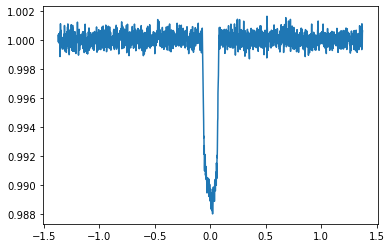

In [11]:
# Load the sample dataset

a = np.loadtxt(
    "./hat-p-70b-copy.csv",
    delimiter=',',
    skiprows=1
)

x_data = a[:,0]
y_data = a[:,1]
yerr_data = a[:,2]
num_data = len(x_data)

plt.plot(x_data,y_data)

### From here, import trace from a run, plot the starry model, and plot traces and corner plot

In [12]:
pwd

'/home/ndiur/Documents/Project/HAT-P-70b/run_30_12_25_c'

In [13]:
# Import trace

# WHICH RUN?
run = "30_12_25"

# THIS looks for concatenated file called FINAL_... modify as needed

csv_name = "FINAL_"+str(run)+".csv"
#csv_name = 'combined.csv'
working_dir = os.getcwd()
print("Reading trace: \n", "Folder: ", working_dir, "\n Filename: ", csv_name)

keep_final = np.loadtxt(
    csv_name,
    delimiter='\t',
    skiprows=0
)

#print(keep_final.shape)
n_samples = len(keep_final)
print("\n Samples: ", n_samples)
burn = int(0.25*n_samples)
print("\n Burn in: ", burn)


Reading trace: 
 Folder:  /home/ndiur/Documents/Project/HAT-P-70b/run_30_12_25_c 
 Filename:  FINAL_30_12_25.csv

 Samples:  405000

 Burn in:  101250


In [14]:
def param_stats(data_array):
    '''
    Takes array of data values and calculates mean, median, 
    standard deviation, and upper and lower 34-percentiles
    
    Input:
        data_array: numpy array of values
    
    Output:
        data_mean: mean
        data_median: median
        data_stdev: standard deviation
        data_sigma_upper: upper 34-percentile (ie, 84th)
        data_sigma_lower: lower 34-percentile (ie, 16th)
    '''
    
    num_data = len(data_array)
    data_mean = np.mean(data_array)
    data_median = np.median(data_array)
    data_stdev = np.std(data_array)
    
    sorted_data = np.sort(data_array)
    lower = sorted_data[int(0.16*num_data)]
    upper = sorted_data[int(0.84*num_data)]
    data_sigma_upper = upper - data_median
    data_sigma_lower = -(lower - data_median)

    return data_mean, data_median, data_stdev, data_sigma_upper, data_sigma_lower
    
    

In [15]:
def psi_calc(istar, iorb, ilam):
    
    istar_rad = np.radians(istar)
    iorb_rad = np.radians(iorb)
    ilam_rad = np.radians(ilam)
    
    cos_psi = (np.cos(istar_rad)*np.cos(iorb_rad)) + (np.sin(istar_rad)*np.sin(iorb_rad)*np.cos(ilam_rad))
    psi_rad = np.arccos(cos_psi)
    psi = np.degrees(psi_rad)
    
    return psi
    


 star_r : 
 mean/stdev =  2.077649028141068 +/- 0.011810044507680988 
 median/34pc =  2.076559573427253 + 0.01291161587355294 - 0.01074248855630655


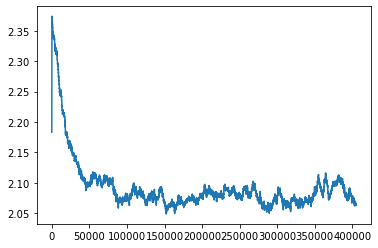


 star_m : 
 mean/stdev =  1.8991744164270552 +/- 0.010909445432142686 
 median/34pc =  1.899669687248604 + 0.011475808352329642 - 0.012843918324998427


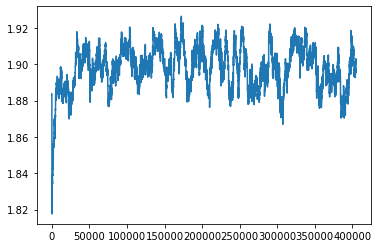


 star_obl : 
 mean/stdev =  0.07144948350860031 +/- 0.001670993454347476 
 median/34pc =  0.07148388990671654 + 0.0018763794878144946 - 0.0018320086934713459


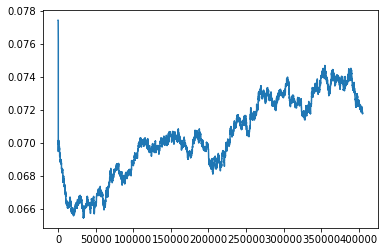


 cos_star_i : 
 mean/stdev =  0.7804705605119213 +/- 0.005513713481953403 
 median/34pc =  0.7798223459537371 + 0.006578090397256098 - 0.005302061389803492


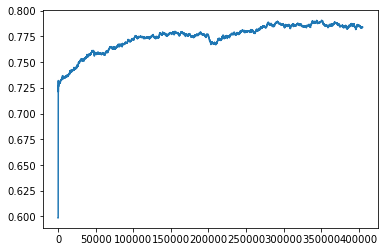


 ratio : 
 mean/stdev =  0.1001800769551076 +/- 0.0002860636275292834 
 median/34pc =  0.10018197717622421 + 0.00029441062757208647 - 0.00029738539482125625


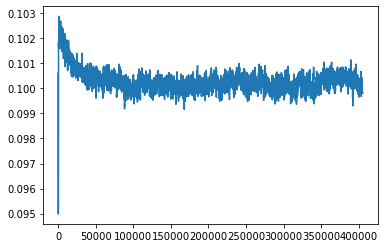


 orb_i : 
 mean/stdev =  97.6043155461844 +/- 0.11965555040739463 
 median/34pc =  97.59227639372985 + 0.13114077859144402 - 0.1082800419968919


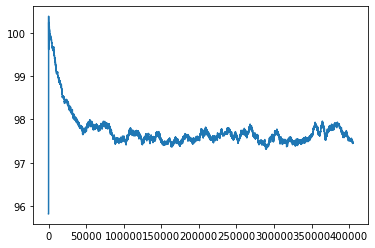


 p_lam : 
 mean/stdev =  105.16195618261523 +/- 3.588427934904897 
 median/34pc =  105.11530409160282 + 3.6712761215331113 - 3.5322038576273656


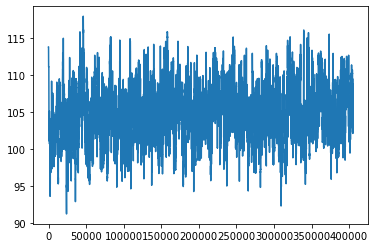


 xo : 
 mean/stdev =  0.0024401633132851348 +/- 0.00021691104753535328 
 median/34pc =  0.002433383652175086 + 0.00022832886757860214 - 0.00020407413688190105


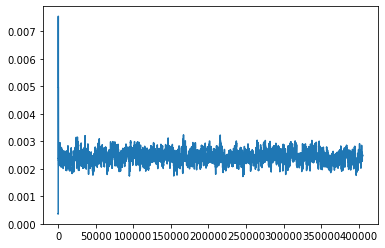


 ys : 
 mean/stdev =  1.0001002608170357 +/- 8.589115230043853e-06 
 median/34pc =  1.0001003825272352 + 8.585439563502106e-06 - 8.81847844858008e-06


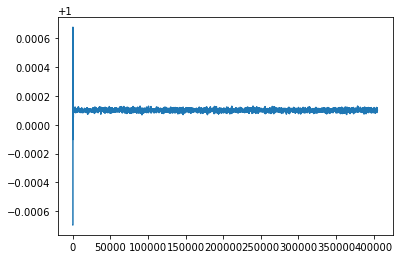

In [16]:
# THIS CELL CHANGED 23/8/24 to display output more clearly
# Posterior samples
post_mean = np.zeros(num_params)
post_median = np.zeros(num_params)
post_sigma_upper = np.zeros(num_params)
post_sigma_lower = np.zeros(num_params)
post_stdev = np.zeros(num_params)

for i in range(num_params):
    # REMOVE THE BURN FROM POSTERIORS
    post_mean[i],post_median[i],post_stdev[i],post_sigma_upper[i],post_sigma_lower[i] = \
    param_stats(keep_final[burn:,i])
    
    #post_mean[i] = np.mean(keep_final[burn:,i])
    #post_median[i] = np.median(keep_final[burn:,i])
    
    #sorted_samples = np.sort(keep_final[burn:,i])
    #post_lower[i] = sorted_samples[int(0.16*len(sorted_samples))] 
    #post_upper[i] = sorted_samples[int(0.84*len(sorted_samples))]
    #post_sigma_upper[i] = post_upper[i] - post_median[i]
    #post_sigma_lower[i] = -(post_lower[i] - post_median[i])

    # Trace plot of parameters (including the burn)
    print("\n",param_names[i],": \n",
          "mean/stdev = ", post_mean[i], "+/-", post_stdev[i], "\n",
          "median/34pc = ", post_median[i], "+",post_sigma_upper[i], "-",post_sigma_lower[i]
         )
    
    # THIS PLOT INCLUDES THE BURN IN - uncomment as needed
    plt.plot(keep_final[0:,i])
    # THIS PLOT EXCLUDES THE BURN IN - uncomment as needed
    #plt.plot(keep_final[burn:,i])
    
    plt.show()



In [17]:
# USES THE COSINE OF STAR INCLINATION
# Transforms from cos(i*) to i* for starry

# Get the final starry model for posterior medians

post_params = np.array([post_median[i] for i in range(num_params)])

# Rename the parameters
star_r, star_m, star_obl, cos_star_i, ratio, orb_i, p_lam, xoff, y_scale = \
      (post_params[i] for i in range(num_params))

# Transform from cosines
star_i = np.degrees(np.arccos(cos_star_i))

# First calculate the expected signal
system_model = gen_starry_model(
    star_r, star_m, star_obl, star_i,
    ratio, orb_i, p_lam, xoff
)
  
flux_model = system_model.flux(
    [x for x in x_data]
)
mu_flux = flux_model * y_scale



Text(0, 0.5, 'Normalised flux')

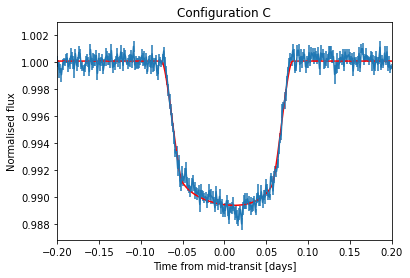

In [18]:
plt.errorbar(x_data,y_data,yerr_data)
plt.plot(x_data,mu_flux,'r-')
plt.xlim(-0.2,+0.2)
plt.title("Configuration C");
plt.xlabel('Time from mid-transit [days]')
plt.ylabel('Normalised flux')

In [19]:
x_out = ((x_data > -0.2)&(x_data < -0.08))|((x_data > 0.08)&(x_data < 0.2))
x_in = (x_data > -0.08)&(x_data < 0.08)
print(x_data[x_in])

[-0.07936375 -0.07797486 -0.07658598 -0.07519709 -0.0738082  -0.07241931
 -0.07103042 -0.06964153 -0.06825264 -0.06686375 -0.06547486 -0.06408598
 -0.06269709 -0.0613082  -0.05991931 -0.05853042 -0.05714153 -0.05575264
 -0.05436375 -0.05297486 -0.05158597 -0.05019709 -0.0488082  -0.04741931
 -0.04603042 -0.04464153 -0.04325264 -0.04186375 -0.04047486 -0.03908598
 -0.03769709 -0.0363082  -0.03491931 -0.03353042 -0.03214153 -0.03075264
 -0.02936375 -0.02797486 -0.02658598 -0.02519709 -0.0238082  -0.02241931
 -0.02103042 -0.01964153 -0.01825264 -0.01686375 -0.01547486 -0.01408598
 -0.01269709 -0.0113082  -0.00991931 -0.00853042 -0.00714153 -0.00575264
 -0.00436375 -0.00297486 -0.00158598 -0.00019709  0.0011918   0.00258069
  0.00396958  0.00535847  0.00674736  0.00813625  0.00952514  0.01091403
  0.01230291  0.0136918   0.01508069  0.01646958  0.01785847  0.01924736
  0.02063625  0.02202514  0.02341403  0.02480291  0.0261918   0.02758069
  0.02896958  0.03035847  0.03174736  0.03313625  0

In [20]:
residuals = (y_data[x_in] - mu_flux[x_in])

# Diagnostics + chi^2
sigma_fit = np.std(residuals)
mean_err  = np.mean(yerr_data[x_in])
scale = np.sqrt(1.374)

#chisq_vals = (residuals / yerr_data[x_in])**2
chisq_vals = (residuals / (yerr_data[x_in]*scale))**2
chisq = np.sum(chisq_vals)

nparam = num_params  # <-- set this to the number of fitted parameters you want to count
ndof = len(y_data[x_in]) - num_params
rchisq = chisq / ndof

print(" Mean error bar:       ", mean_err, "\n",
      "Standard dev. of fit: ", sigma_fit, "\n",
      "Parameters fitted:    ", nparam, "\n",
      "Chi squared:          ", chisq, "\n",
      "NDOF:                 ", ndof, "\n",
      "Reduced chi squared:  ", rchisq, "\n",
     )

 Mean error bar:        0.00041167780000000005 
 Standard dev. of fit:  0.00048418226394462554 
 Parameters fitted:     9 
 Chi squared:           144.29457597321456 
 NDOF:                  106 
 Reduced chi squared:   1.3612695846529677 



In [21]:
residuals = y_data[x_out] - mu_flux[x_out]

# Diagnostics + chi^2
sigma_fit = np.std(residuals)
mean_err  = np.mean(yerr_data[x_out])
scale = np.sqrt(1.374)

#chisq_vals = (residuals / yerr_data[x_out])**2
chisq_vals = (residuals / (yerr_data[x_out]*scale))**2
chisq = np.sum(chisq_vals)

nparam = num_params  # <-- set this to the number of fitted parameters you want to count
ndof = len(y_data[x_out]) - num_params
rchisq = chisq / ndof

print(" Mean error bar:       ", mean_err, "\n",
      "Standard dev. of fit: ", sigma_fit, "\n",
      "Parameters fitted:    ", nparam, "\n",
      "Chi squared:          ", chisq, "\n",
      "NDOF:                 ", ndof, "\n",
      "Reduced chi squared:  ", rchisq, "\n",
     )

 Mean error bar:        0.00040640586705202315 
 Standard dev. of fit:  0.00042657249060510446 
 Parameters fitted:     9 
 Chi squared:           164.02554577990105 
 NDOF:                  164 
 Reduced chi squared:   1.0001557669506163 



Text(0, 0.5, 'Flux residuals')

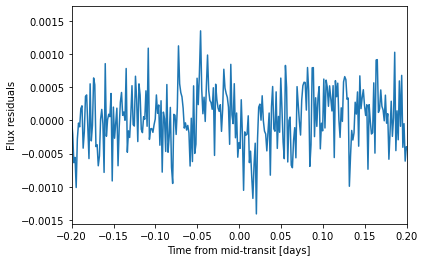

In [22]:
residuals = y_data-mu_flux
plt.plot(x_data,residuals)
plt.xlim(-0.2,+0.2)
plt.xlabel('Time from mid-transit [days]')
plt.ylabel('Flux residuals')

In [23]:
# THIS CELL CHANGED 23/8/24 to generate more derived outputs

print("Posterior means, medians and 34 percentiles: \n")
for i in range(num_params):
    print("\n", param_names[i],": ", "\n",
          "mean/stdev = ",post_mean[i], "+/-", post_stdev[i], "\n",
          "median/34pc = ", post_median[i],
          "+",post_sigma_upper[i],
          "-",post_sigma_lower[i], 
         )

# Rename the parameters
star_r, star_m, star_obl, cos_star_i, ratio, orb_i, p_lam, xoff, y_scale = \
      (post_params[i] for i in range(num_params))

# Transform from cosines
star_i = np.degrees(np.arccos(cos_star_i))
# manage the cosines
# y = cos (x*pi/180)
# dy = |sin (x*pi/180) *pi/180 *dx|

# If using cosine of the star inclination
rotinc_rad = np.arccos(cos_star_i)
cos_rotinc_rad_err = post_stdev[3]
rotinc_rad_err = cos_rotinc_rad_err/np.sin(rotinc_rad)
rotinc_err = 180.0/np.pi * rotinc_rad_err

# Calculate vsini*
star_vsini = vsini_calc(star_r, star_m, star_i, star_obl)

# Derived planet/orbit quantities
planet_r = star_r * ratio
sma, areq = sma_calc(planet.porb, star_m, star_r)
psi_val = psi_calc(star_i,orb_i,p_lam)
beta_val = star_grav(star_obl)

print("\n Vsini (km/sec): ",star_vsini,
     "\n Planet radius (R_sun): ", planet_r,
     "\n Semi-major axis (AU): ", sma,
     "\n a/R_eq_star: ", areq,
     "\n star_inc: ", star_i, " +/- ", rotinc_err,
     "\n psi: ", psi_val,
     "\n beta: ", beta_val,
     )

Posterior means, medians and 34 percentiles: 


 star_r :  
 mean/stdev =  2.077649028141068 +/- 0.011810044507680988 
 median/34pc =  2.076559573427253 + 0.01291161587355294 - 0.01074248855630655

 star_m :  
 mean/stdev =  1.8991744164270552 +/- 0.010909445432142686 
 median/34pc =  1.899669687248604 + 0.011475808352329642 - 0.012843918324998427

 star_obl :  
 mean/stdev =  0.07144948350860031 +/- 0.001670993454347476 
 median/34pc =  0.07148388990671654 + 0.0018763794878144946 - 0.0018320086934713459

 cos_star_i :  
 mean/stdev =  0.7804705605119213 +/- 0.005513713481953403 
 median/34pc =  0.7798223459537371 + 0.006578090397256098 - 0.005302061389803492

 ratio :  
 mean/stdev =  0.1001800769551076 +/- 0.0002860636275292834 
 median/34pc =  0.10018197717622421 + 0.00029441062757208647 - 0.00029738539482125625

 orb_i :  
 mean/stdev =  97.6043155461844 +/- 0.11965555040739463 
 median/34pc =  97.59227639372985 + 0.13114077859144402 - 0.1082800419968919

 p_lam :  
 mean/stdev =  

In [24]:
# THIS CELL ADDED 23/8/24 to show how to generate statistics for derived parameters from the trace

# get statistics of derived parameters by drawing from the trace
derived_names = ["star_vsini",
                 "planet_r",
                 "sma",
                 "areq",
                 "psi",
                 "star_i"
                 "beta"
                ]

num_derived = len(derived_names)

derived_vsini = []
derived_planet_r = []
derived_sma = []
derived_areq = []
derived_psi = []
derived_star_i = []
derived_beta = []

# Rename the parameters and calculate for each line of the trace -- use samples only *after* the burn-in

samples = keep_final[burn:,:]

for j in range(len(samples)):
    star_r, star_m, star_obl, cos_star_i, ratio, orb_i, p_lam, xoff, y_scale = \
      (samples[j,i] for i in range(num_params))
    
    # Transform from cosines
    star_i = np.degrees(np.arccos(cos_star_i))

    star_vsini = vsini_calc(star_r, star_m, star_i, star_obl)
    planet_r = star_r * ratio
    sma, areq = sma_calc(planet.porb, star_m, star_r)
    psi_val = psi_calc(star_i,orb_i,p_lam)
    beta_val = star_grav(star_obl)
    
    # append values to array for stats calculation
    derived_vsini.append(star_vsini)
    derived_planet_r.append(planet_r)
    derived_sma.append(sma)
    derived_areq.append(areq)
    derived_psi.append(psi_val)
    derived_star_i.append(star_i)
    derived_beta.append(beta_val)



In [25]:
# Test the results (clumsy)
mean1,median1,stdev1,upper1,lower1 = param_stats(np.array(derived_star_i))
print(mean1,stdev1,median1,upper1,lower1)

mean1,median1,stdev1,upper1,lower1 = param_stats(np.array(derived_beta))
print(mean1,stdev1,median1,upper1,lower1)

38.693544478159154 0.5048663790082338 38.755687557397536 0.4827522996467124 0.6060752070612097
0.22660779201137457 0.0005152869458965754 0.22659707906828225 0.0005650589422237784 0.0005784880703509632


In [26]:
import corner

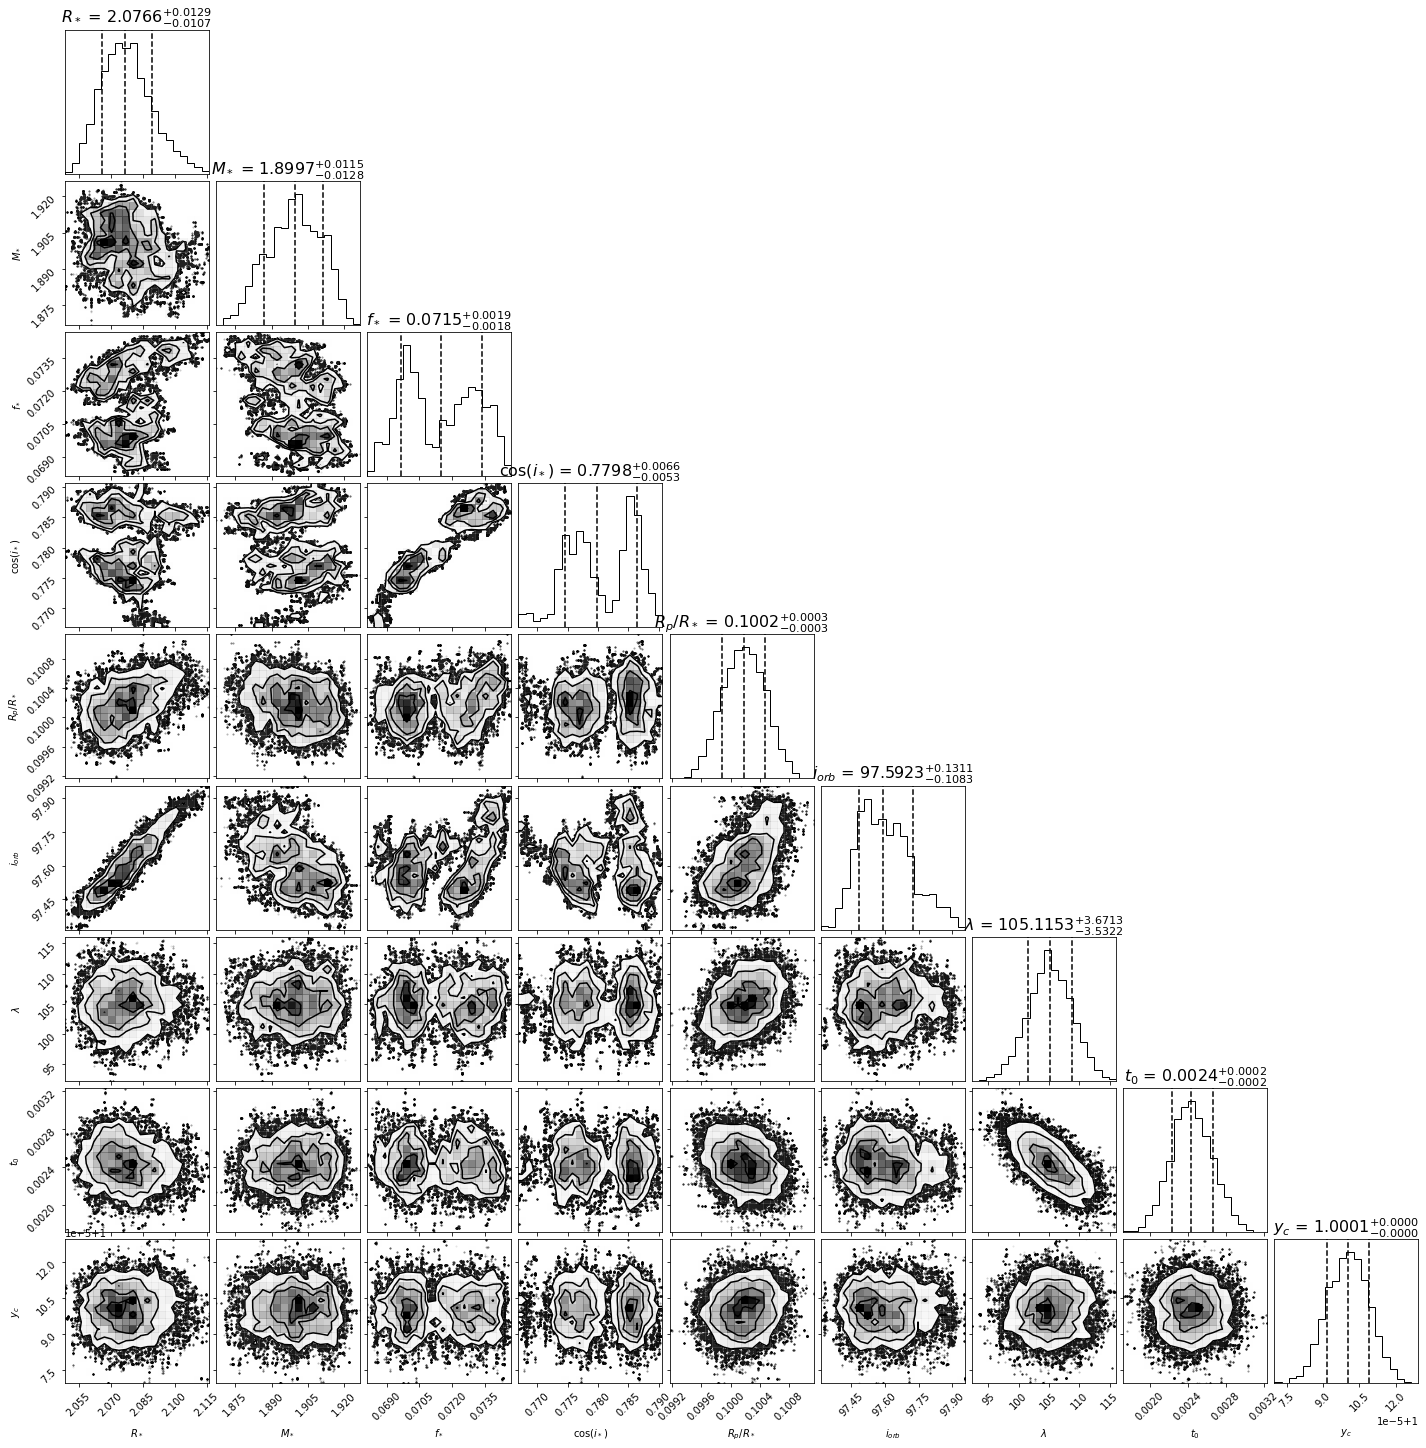

In [27]:
tex_names = ["R_*", 
             "M_*", 
             "f_*", 
             "\cos(i_*)", 
             "R_p/R_*", 
             "i_{orb}", 
             "\lambda", 
             "t_0", 
             "y_c",
              ]

samples = keep_final[burn:,:]

figure = corner.corner(
    samples,
    var_names = param_names,
    #labels = [param_names[i] for i in range(num_params)],
    labels = [r"$"+tex_names[i]+"$" for i in range(len(tex_names))],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt = ".4f",
    #truths={"oot_A": oot_A, 
    #        "depth_b": depth_b, 
    #        "t_centre": t_centre, 
    #        "t_width": t_width},
    title_kwargs={"fontsize": 16},
)